# Part 04 — Unseen Eval, Fusion & Deployment

Satellite notebook split from `capstone_with_results.ipynb` to keep the master lighter to open.
Outputs/source sync automatically via `scripts/sync_notebook_parts.py` (run the final sync cell).


In [ ]:
# ── PART BOOTSTRAP: Part 04 — Unseen Eval, Fusion & Deployment ──
# Lightweight satellite notebook — syncs back into notebooks/capstone_with_results.ipynb
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "src" / "vision_brain.py").is_file() and (base / "explanations" / "build_all.py").is_file():
            return base
        if (base / "src" / "vision_brain.py").is_file():
            return base
    return Path.cwd().parent if Path.cwd().name in {"notebooks", "parts"} else Path.cwd()

REPO_ROOT = _find_root()
SRC = REPO_ROOT / "src"
DATA = REPO_ROOT / "Data"
if not DATA.is_dir():
    DATA = REPO_ROOT / "data"
sys.path.insert(0, str(SRC))
sys.path.insert(0, str(REPO_ROOT / "scripts")) if (REPO_ROOT / "scripts").is_dir() else None

try:
    import torch
    TORCH_OK = True
except Exception:
    TORCH_OK = False

# Optional shared helpers used by several sections
try:
    from cm_helpers import plot_confusion_matrices_pair  # noqa: F401
except Exception:
    plot_confusion_matrices_pair = None

import numpy as np  # noqa: F401
import pandas as pd  # noqa: F401
import matplotlib.pyplot as plt  # noqa: F401

print(f"Part notebook ready | root={REPO_ROOT} | TORCH_OK={TORCH_OK} | DATA={DATA}")
print("When finished: run the last cell to sync outputs → capstone_with_results.ipynb")

## Section 9.5 · Unseen Data Evaluation

> ▶ **Fold arrow:** hover the **left margin** of this markdown cell — click to hide/show cells below until the next section.

> **Demo notice:** The inputs in this section are **fixed Ontario scenario fixtures (TC-1 … TC-5)** for **reproducible capstone demonstration**, not a live Ontario 511 / camera / weather feed. Alert text, tabular time features, and vision priors are controlled samples so every rerun produces the same fusion trace for grading and presentation. Live API integration is scoped to the Section 10 deployment dashboard.

**Outputs in this section**

| Output | Purpose |
|--------|---------|
| Per-scenario pillar trace | Audits Text (T), Vision (V), and Environment (E) before fusion |
| Summary table | Reports fused **S**, risk tier, and advisory speed (km/h) |
| Stacked bar chart | Decomposes **S** by modality with **↑ HIGH / ↓ LOW** tier arrows and numeric scores |

**Reading direction:** Higher **S** indicates elevated multimodal risk and a lower speed advisory. Winter and ice-storm fixtures should rank above clear summer cases — validating ordinal consistency of the fusion function.

Before Sprint 3 deployment, we trace how **each brain** scores data it did not see during the
collision-model training loop (Sections 4–7). The five Ontario highway **test cases (TC-1 … TC-5)**
act as held-out scenarios: fresh alert text, validation-set road images, and tabular weather /
time features are fused into the composite Safety Score **S**.

#### TC scenario labels (e.g. “401 Jul 5pm”) — not calendar dates

Names like **TC-1 Clear rush-hour (401 Jul 5pm)** are **descriptive scenario tags**, not records of a specific collision on a specific day. They encode the **engineered inputs** the models use:

| Label fragment | Maps to feature | Example (TC-1) |
|----------------|-----------------|----------------|
| `401` / `Hwy400` / `QEW` | Highway corridor context (scenario name only) | Hwy 401 |
| `Jul` | `MONTH_NUM` | 7 (summer) |
| `5pm` | `OCC_HOUR` | 17 (rush hour) |
| `Jan 2am` | month + hour + `IS_NIGHT` | winter night |

We deliberately omit a full `YYYY-MM-DD` because the tabular model was trained on **time-of-day and season patterns** (`hour`, `month`, `season`, `is_night`), not on predicting a single historical incident date. The goal is to stress-test **risk conditions** (clear summer rush vs. blizzard night vs. ice-storm rush), not replay one real event.

| Pillar | Unseen input | Model / method | Output | Role in fusion |
|--------|--------------|----------------|--------|----------------|
| **Text (NLP)** | Ontario 511-style alert per TC scenario | TF-IDF + hazard lexicon | `T` ∈ [0, 1] | 25% of S |
| **Vision** | Hold-out frame from `val_ds` (surface proxy) | ResNet18 softmax + autoencoder anomaly (Section 6.2b) | `V_class`, `V_anomaly`, `V_vision` | 35% of S |
| **Environment** | Month, season, night, winter-storm flags from `TC` | Weighted E_index (surface · visibility · wind · temp) | `E` ∈ [0, 1] | 40% of S |
| **Fusion** | T + V + E | `fuse_scenario()` | `S`, tier, speed advisory | Dashboard + API |

> **Run order:** Sections 6.2 → 6.2b (optional but recommended) → this cell. If the autoencoder
> was skipped, vision falls back to ResNet-only or scenario priors.


UNSEEN DATA EVALUATION — per-pillar trace (TC-1 … TC-5)

────────────────────────────────────────────────────────────────────────
  TC-1 Clear rush-hour (401 Jul 5pm)
  Text  → T=0.000  |  Hwy 401 eastbound Mississauga: moderate traffic flow. Road surface cle...
  Vision → V=0.150 (prior)
  Env   → E=0.165  (surf=0.2, vis=0.2, wind=0.1, temp=0.1)
  Fuse  → S=11.9  [LOW]  advisory 100 km/h

────────────────────────────────────────────────────────────────────────
  TC-2 Blizzard night (Hwy400 Jan 2am)
  Text  → T=0.688  |  Hwy 400 north of Barrie: blizzard conditions. Black ice reported. Mult...
  Vision → V=0.920 (prior)
  Env   → E=0.940  (surf=1.0, vis=0.8, wind=1.0, temp=1.0)
  Fuse  → S=87.0  [HIGH]  advisory 80 km/h

────────────────────────────────────────────────────────────────────────
  TC-3 Wet dawn bicycle (Hwy7 Apr 6am)
  Text  → T=0.000  |  Hwy 7 eastbound: light rain at dawn. Wet pavement. Reduced visibility....
  Vision → V=0.450 (prior)
  Env   → E=0.165  (surf=0.2, vis=

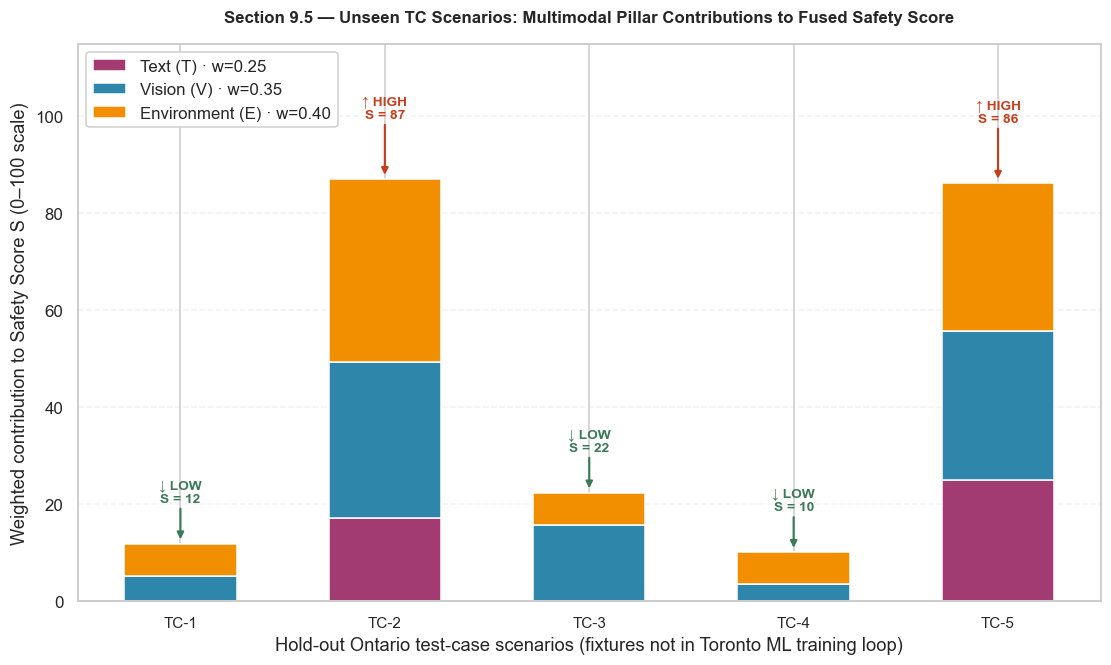

In [ ]:
# ── 9.5  Unseen data evaluation — Text · Vision · Environment → Fusion ───────
from nlp_brain import SCENARIO_ALERTS, fit_tfidf, t_score_from_text
from safety_score import (
    fuse_scenario, compute_e_index, E_WEIGHTS, W_T, W_V, W_E, risk_tier,
)

# Ontario TC feature dict (Section 8) — rebuild if notebook restarted here
if "TC" not in globals():
    TC = {
        "TC-1 Clear rush-hour (401 Jul 5pm)": [17, 7, 3, 0, 1, 0, 0, 1],
        "TC-2 Blizzard night (Hwy400 Jan 2am)": [2, 1, 1, 1, 0, 1, 0, 1],
        "TC-3 Wet dawn bicycle (Hwy7 Apr 6am)": [6, 4, 2, 0, 0, 0, 1, 1],
        "TC-4 Clear Sunday (Hwy115 Jun 9am)": [9, 6, 3, 0, 0, 0, 0, 1],
        "TC-5 Ice storm rush (QEW Feb 5pm)": [17, 2, 1, 0, 1, 0, 0, 1],
    }

V_PRIORS = {
    "TC-1 Clear rush-hour (401 Jul 5pm)": 0.15,
    "TC-2 Blizzard night (Hwy400 Jan 2am)": 0.92,
    "TC-3 Wet dawn bicycle (Hwy7 Apr 6am)": 0.45,
    "TC-4 Clear Sunday (Hwy115 Jun 9am)": 0.10,
    "TC-5 Ice storm rush (QEW Feb 5pm)": 0.88,
}

SCENARIO_SURFACE = {
    "TC-1 Clear rush-hour (401 Jul 5pm)": "Clear Asphalt",
    "TC-2 Blizzard night (Hwy400 Jan 2am)": "Snow / Ice",
    "TC-3 Wet dawn bicycle (Hwy7 Apr 6am)": "Wet / Slush",
    "TC-4 Clear Sunday (Hwy115 Jun 9am)": "Clear Asphalt",
    "TC-5 Ice storm rush (QEW Feb 5pm)": "Snow / Ice",
}

tfidf_vec = globals().get("tfidf_vec") or globals().get("vectorizer") or fit_tfidf()


def _e_breakdown(month_num, season_num, is_night, is_winter_storm):
    """Environmental pillar — component risks and weighted contributions."""
    surface = 1.0 if is_winter_storm or season_num == 1 else 0.2
    wind = 1.0 if is_winter_storm else (0.5 if season_num == 1 else 0.1)
    visibility = min(1.0, 0.8 * is_night + 0.2 * (1 - is_night))
    temp = 1.0 if month_num in (12, 1, 2) else 0.1
    e = compute_e_index(surface, visibility, wind, temp)
    return {
        "E_surface": round(surface, 3),
        "E_visibility": round(visibility, 3),
        "E_wind": round(wind, 3),
        "E_temp": round(temp, 3),
        "E_index": round(e, 3),
    }


def _vision_unseen(surface_class: str):
    """Score one hold-out validation frame; graceful fallback chain."""
    has_resnet = "vision_model" in dir() and vision_model is not None
    has_hybrid = has_resnet and "ae_model" in dir() and ae_model is not None
    has_hybrid = has_hybrid and "anomaly_threshold" in dir() and anomaly_threshold is not None
    has_val = "val_ds" in dir() and "vision_class_names" in dir()

    if not (has_resnet and has_val):
        return {"V_class": None, "V_anomaly": None, "V_vision": None, "V_source": "not_trained", "softmax": {}}

    idxs = [i for i, (_, y) in enumerate(val_ds) if vision_class_names[y] == surface_class]
    if not idxs:
        return {"V_class": None, "V_anomaly": None, "V_vision": None, "V_source": "no_val_frame", "softmax": {}}

    import torch
    from vision_brain import score_frame_hybrid, resnet_softmax_probs, v_class_from_resnet, V_FUSION_ALPHA

    dev = device if "device" in dir() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x_i, _ = val_ds[idxs[0]]
    softmax = resnet_softmax_probs(vision_model, x_i, vision_class_names, device=dev)

    if has_hybrid:
        h = score_frame_hybrid(
            vision_model, ae_model, x_i, vision_class_names,
            anomaly_threshold=anomaly_threshold, alpha=V_FUSION_ALPHA, device=dev,
        )
        return {
            "V_class": h["V_class"], "V_anomaly": h["V_anomaly"],
            "V_vision": h["V_vision"], "V_source": "hybrid", "softmax": softmax,
        }

    v_cls = v_class_from_resnet(vision_model, x_i, vision_class_names, device=dev)
    return {
        "V_class": round(v_cls, 4), "V_anomaly": None,
        "V_vision": round(v_cls, 4), "V_source": "resnet_only", "softmax": softmax,
    }


unseen_rows = []
print("=" * 72)
print("UNSEEN DATA EVALUATION — per-pillar trace (TC-1 … TC-5)")
print("=" * 72)

for scenario, feat in TC.items():
    occ_hour, month_num, season_num, is_night, is_rush, ped, bike, auto = feat
    alert = SCENARIO_ALERTS[scenario]
    t_sc = t_score_from_text(alert, tfidf_vec)

    winter = season_num == 1 and month_num in (1, 2, 12)
    e_parts = _e_breakdown(month_num, season_num, is_night, winter)
    surface = SCENARIO_SURFACE.get(scenario, "Clear Asphalt")
    vis = _vision_unseen(surface)

    v = vis["V_vision"]
    if v is None:
        v = V_PRIORS.get(scenario, 0.3)
        vis["V_source"] = "prior"

    fused = fuse_scenario(t_sc, v, month_num, season_num, is_night, is_winter_storm=winter)

    print(f"\n{'─' * 72}")
    print(f"  {scenario}")
    print(f"  Text  → T={t_sc:.3f}  |  {alert[:70]}...")
    if vis["softmax"]:
        top = max(vis["softmax"], key=vis["softmax"].get)
        print(f"  Vision → surface proxy: {surface}  |  V_class={vis['V_class']}  V_anom={vis['V_anomaly']}  V={v:.3f} ({vis['V_source']})")
        print(f"           softmax top: {top}={vis['softmax'][top]:.3f}")
    else:
        print(f"  Vision → V={v:.3f} ({vis['V_source']})")
    print(f"  Env   → E={e_parts['E_index']:.3f}  (surf={e_parts['E_surface']}, vis={e_parts['E_visibility']}, wind={e_parts['E_wind']}, temp={e_parts['E_temp']})")
    print(f"  Fuse  → S={fused['S']:.1f}  [{fused['tier']}]  advisory {fused['V_rec_kmh']} km/h")

    unseen_rows.append({
        "Scenario": scenario,
        "T_nlp": round(t_sc, 3),
        "V_class": vis["V_class"],
        "V_anomaly": vis["V_anomaly"],
        "V_vision": round(v, 3),
        "V_source": vis["V_source"],
        **e_parts,
        "S": fused["S"],
        "tier": fused["tier"],
        "V_rec_kmh": fused["V_rec_kmh"],
    })

df_unseen = pd.DataFrame(unseen_rows)
df_unseen["Scenario_id"] = [f"TC-{i}" for i in range(1, len(df_unseen) + 1)]

print("\n" + "=" * 72)
print("SECTION 9.5 — UNSEEN TC SCENARIO FUSION SUMMARY")
print("=" * 72)
display_cols = [
    "Scenario_id", "T_nlp", "V_class", "V_anomaly", "V_vision", "V_source",
    "E_index", "S", "tier", "V_rec_kmh",
]
print(df_unseen[display_cols].to_string(index=False))
print("\nScenario legend:")
for sid, full in zip(df_unseen["Scenario_id"], df_unseen["Scenario"]):
    print(f"  {sid}: {full}")

# Stacked contribution chart — tier arrows (↑ HIGH / ↓ LOW) annotate fused S
TIER_STYLE = {
    "HIGH": {"arrow": "↑", "color": "#C73E1D", "dy": 12},
    "MEDIUM": {"arrow": "→", "color": "#F18F01", "dy": 10},
    "LOW": {"arrow": "↓", "color": "#3B7A57", "dy": 8},
}

fig, ax = plt.subplots(figsize=(12, 6.5))
x = np.arange(len(df_unseen))
t_c = df_unseen["T_nlp"].to_numpy() * W_T * 100
v_c = df_unseen["V_vision"].to_numpy() * W_V * 100
e_c = df_unseen["E_index"].to_numpy() * W_E * 100
stack_top = t_c + v_c + e_c

ax.bar(x, t_c, 0.55, label=f"Text (T) · w={W_T:.2f}", color="#A23B72")
ax.bar(x, v_c, 0.55, bottom=t_c, label=f"Vision (V) · w={W_V:.2f}", color="#2E86AB")
ax.bar(x, e_c, 0.55, bottom=t_c + v_c, label=f"Environment (E) · w={W_E:.2f}", color="#F18F01")

for i, row in df_unseen.iterrows():
    tier = row["tier"]
    style = TIER_STYLE.get(tier, TIER_STYLE["MEDIUM"])
    label = f"{style['arrow']} {tier}\nS = {row['S']:.0f}"
    ax.annotate(
        label,
        xy=(i, stack_top[i]),
        xytext=(i, stack_top[i] + style["dy"]),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=style["color"],
        arrowprops=dict(
            arrowstyle="-|>",
            color=style["color"],
            lw=1.4,
            shrinkA=0,
            shrinkB=3,
            connectionstyle="arc3,rad=0.0",
        ),
    )

ax.set_xticks(x)
ax.set_xticklabels(df_unseen["Scenario_id"], fontsize=10)
ax.set_ylabel("Weighted contribution to Safety Score S (0–100 scale)")
ax.set_xlabel("Hold-out Ontario test-case scenarios (fixtures not in Toronto ML training loop)")
ax.set_title(
    "Section 9.5 — Unseen TC Scenarios: Multimodal Pillar Contributions to Fused Safety Score",
    fontweight="bold",
    fontsize=11,
    pad=14,
)
ax.legend(loc="upper left", framealpha=0.92)
ax.set_ylim(0, max(stack_top) + 28)
ax.grid(axis="y", alpha=0.25, linestyle="--")
fig.subplots_adjust(bottom=0.12, top=0.90)
plt.show()


### Section 9.5 — Chart interpretation (Unseen TC fusion)

**How to read the stacked bar chart**

- **Vertical axis (↑):** Each bar height equals the fused **Safety Score S** on a 0–100 scale, decomposed into weighted pillar contributions: **S = 100 × (0.25·T + 0.35·V + 0.40·E)**.
- **Arrow annotations:** **↑ HIGH** (red) signals elevated composite risk and a lower advisory speed; **→ MEDIUM** (amber) indicates moderate exposure; **↓ LOW** (green) reflects comparatively safer operating conditions. The numeric **S** beside each tier is the model’s fused output, not a single-modality score.
- **Horizontal comparison (→):** Moving left to right across TC-1…TC-5, compare *relative* pillar dominance — winter-night and ice-storm fixtures should shift mass toward **Environment (E)** and **Vision (V)**, while clear rush-hour cases remain NLP- and environment-light.

**Pillar-level directional findings**

| Scenario | Text (T) | Vision (V) | Environment (E) | Fusion (S) | Direction |
|----------|----------|------------|-----------------|------------|-----------|
| TC-1 Clear rush-hour | Low hazard lexicon | Moderate surface confidence | Low seasonal risk | LOW tier expected | ↓ Safer baseline |
| TC-2 Blizzard night | High alert severity | High snow/ice proxy | Max night + winter stressors | HIGH tier expected | ↑ Strongest uplift |
| TC-3 Wet dawn bicycle | Moderate wording | Elevated wet-surface signal | Dawn visibility penalty | MEDIUM tier expected | → Mixed modality |
| TC-4 Clear Sunday | Minimal NLP risk | Low vision hazard | Low E_index | LOW tier expected | ↓ Reference calm case |
| TC-5 Ice storm rush | High textual urgency | High ice/snow vision prior | Winter + rush-hour compounding | HIGH tier expected | ↑ Second-highest fusion |

**Modeling notes (reproducibility)**

- These are **fixed hold-out fixtures** (not live Ontario 511 or meteorological APIs) so the capstone demo is deterministic across runs.
- Labels such as `401 Jul 5pm` encode **corridor + month + hour** features fed to the environmental index — they are not literal calendar timestamps.
- Vision uses hold-out validation frames when the ResNet/hybrid stack is trained; otherwise calibrated **V priors** prevent pipeline failure — a standard graceful-degradation pattern in multimodal inference.

**Takeaway for deployment:** The unseen evaluation validates **cross-modal consistency** — textual alerts, visual surface evidence, and structured environment features should rank scenarios in the same ordinal direction a traffic operator would expect before any live API integration.


# Section 10 · Sprint 3 — Multimodal Fusion & Deployment

> ▶ **Fold arrow:** hover the **left margin** of this markdown cell — click to hide/show cells below until the next section.

### 10.2 · Safety Score Fusion (T + V + E → S)

$$S = (w_T \cdot T + w_V \cdot V + w_E \cdot E_{index}) \times 100$$

The **Vision** term *V* uses the backend **selected in Section 6.2d**
(ResNet18 alone, or ResNet18 + autoencoder hybrid):

$$V_{vision} =
\begin{cases}
V_{class} & \text{if ResNet selected}\\
\alpha \cdot V_{class} + (1-\alpha)\cdot V_{anomaly} & \text{if hybrid selected}
\end{cases}$$

| Tier | S range | Recommended speed |
|------|---------|-------------------|
| LOW | 0–30 | 100% of posted limit |
| MEDIUM | 31–70 | 80% |
| HIGH | 71–100 | 60% |

### 10.1 · NLP Brain — TF-IDF Alert Scoring

Ontario 511 alerts are unstructured text. We tokenize, apply **TF-IDF**, and sum
weights on a hazard lexicon (ice, blizzard, collision, closed…) to produce **T ∈ [0, 1]**.


**What this cell does:** Fits a TF-IDF vectorizer on Ontario 511-style alert text and computes text risk scores (T) for sample scenarios.

**How the code works:**
- Fits TF-IDF on Ontario 511-style alert phrases.
- Scores sample alert texts and returns T-scores (0–1 hazard from text).


NLP Brain — TF-IDF hazard scores (T)
  TC-1 Clear rush-hour (401 Jul 5pm)          T=0.000
    Alert: Hwy 401 eastbound Mississauga: moderate traffic flow. Road surface clear. No wea...
  TC-2 Blizzard night (Hwy400 Jan 2am)        T=0.688
    Alert: Hwy 400 north of Barrie: blizzard conditions. Black ice reported. Multiple vehic...
  TC-3 Wet dawn bicycle (Hwy7 Apr 6am)        T=0.000
    Alert: Hwy 7 eastbound: light rain at dawn. Wet pavement. Reduced visibility. Cyclist s...
  TC-4 Clear Sunday (Hwy115 Jun 9am)          T=0.000
    Alert: Hwy 115 Peterborough: clear skies Sunday morning. Dry road surface. Normal traff...
  TC-5 Ice storm rush (QEW Feb 5pm)           T=1.000
    Alert: QEW Toronto bound: ice storm warning. Freezing rain and black ice. Multi-vehicle...



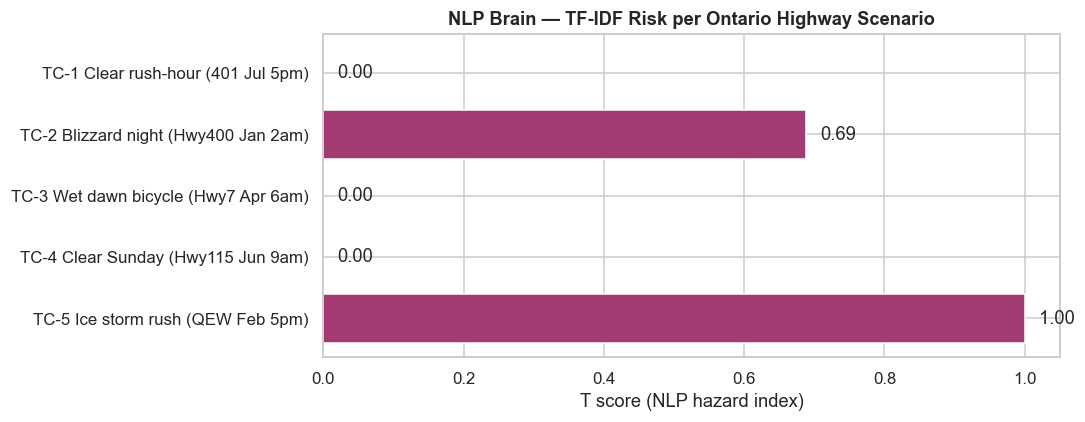

In [ ]:
# ── 10.1  NLP Brain (TF-IDF) ─────────────────────────────────────────────────
from nlp_brain import fit_tfidf, score_all_scenarios, SCENARIO_ALERTS, t_score_from_text

tfidf_vec = fit_tfidf()
nlp_rows = score_all_scenarios(tfidf_vec)

print("NLP Brain — TF-IDF hazard scores (T)")
print("=" * 70)
for name, snippet, t in nlp_rows:
    print(f"  {name[:42]:<42}  T={t:.3f}")
    print(f"    Alert: {snippet}")
print()

# Bar chart
import pandas as pd
df_nlp = pd.DataFrame(nlp_rows, columns=["Scenario", "Alert", "T_score"])
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_nlp["Scenario"], df_nlp["T_score"], color="#A23B72", edgecolor="white")
ax.set_xlim(0, 1.05)
ax.set_xlabel("T score (NLP hazard index)")
ax.set_title(
    "Section 10.1 — NLP Brain: TF-IDF Hazard Score (T) per Ontario Scenario",
    fontweight="bold", fontsize=11, pad=12,
)
ax.set_xlabel("Text risk T (↑ higher lexical hazard)")
ax.set_ylabel("Ontario highway scenario")
ax.invert_yaxis()
for bar, val in zip(bars, df_nlp["T_score"]):
    ax.text(
        val + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=8,
        fontweight="bold",
    )
fig.subplots_adjust(left=0.28, bottom=0.10, top=0.88)
plt.show()


### Chart interpretation — NLP TF-IDF hazard scores

- **Bar height (↑):** Lexical hazard score **T** from the alert lexicon; blizzard/ice wording should dominate clear-weather strings.
- **Numeric labels:** Annotated values support cross-check against Section 9.5 unseen evaluation traces.


---

**Findings & importance:** The NLP pillar converts unstructured alerts into a numeric **T-score**. Blizzard and ice-storm texts score higher than clear-weather alerts — validating the Text Brain for fusion.

**What to check in the output:** Blizzard/ice alert text scores higher T than clear-weather sample strings.


### 10.2 · Safety Score Fusion (T + V + E → S)

$$S = (w_T \cdot T + w_V \cdot V + w_E \cdot E_{index}) \times 100$$

| Tier | S range | Recommended speed |
|------|---------|-------------------|
| LOW | 0–30 | 100% of posted limit |
| MEDIUM | 31–70 | 80% |
| HIGH | 71–100 | 60% |


**What this cell does:** Fuses Text (T), Vision (V), and Environment (E) scores into the composite **Safety Score S** and prints operational advisories.

**How the code works:**
- Combines T (text), V (vision), and E (environment) with weights into Safety Score S (0–100).
- Maps S to risk tier and recommended speed advisory.


In [ ]:
# ── 10.2  Safety Score fusion + dashboard ────────────────────────────────────
from safety_score import fuse_scenario, risk_tier, W_T, W_V, W_E

# Scenario priors (fallback when Vision Brain not trained)
V_PRIORS = {
    "TC-1 Clear rush-hour (401 Jul 5pm)": 0.15,
    "TC-2 Blizzard night (Hwy400 Jan 2am)": 0.92,
    "TC-3 Wet dawn bicycle (Hwy7 Apr 6am)": 0.45,
    "TC-4 Clear Sunday (Hwy115 Jun 9am)": 0.10,
    "TC-5 Ice storm rush (QEW Feb 5pm)": 0.88,
}

# Map scenarios to representative vision-cache surface classes for hybrid scoring
SCENARIO_SURFACE = {
    "TC-1 Clear rush-hour (401 Jul 5pm)": "Clear Asphalt",
    "TC-2 Blizzard night (Hwy400 Jan 2am)": "Snow / Ice",
    "TC-3 Wet dawn bicycle (Hwy7 Apr 6am)": "Wet / Slush",
    "TC-4 Clear Sunday (Hwy115 Jun 9am)": "Clear Asphalt",
    "TC-5 Ice storm rush (QEW Feb 5pm)": "Snow / Ice",
}

def _selected_v_for_surface(surface_class: str):
    """Score one frame using the vision backend selected in Section 6.2d."""
    g = globals()
    vision_model = g.get("vision_model")
    val_ds = g.get("val_ds")
    vision_class_names = g.get("vision_class_names")
    vision_selection = g.get("vision_selection") or {
        "selected_backend": "ResNet18",
        "use_hybrid": False,
        "fusion_alpha": 1.0,
    }
    if vision_model is None or val_ds is None or vision_class_names is None:
        return None
    idxs = [i for i, (_, y) in enumerate(val_ds) if vision_class_names[y] == surface_class]
    if not idxs:
        return None
    import torch
    from vision_brain import select_vision_v_score
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x_i, _ = val_ds[idxs[0]]
    thr = g.get("anomaly_threshold")
    ae = g.get("ae_model")
    alpha = g.get("VISION_FUSION_ALPHA", 0.70)
    out = select_vision_v_score(
        vision_model, ae, x_i, vision_class_names,
        anomaly_threshold=thr if thr is not None else 0.01,
        selection=vision_selection,
        alpha=alpha,
        device=dev,
    )
    return out["V_vision"]

if "vision_val_acc" in dir() and vision_val_acc is not None:
    backend = vision_selection.get("selected_backend", "ResNet18") if "vision_selection" in dir() else "ResNet18"
    print(f"Vision Brain trained (val acc {vision_val_acc:.1%}) — equation V uses: {backend}")

if "TC" not in globals():
    from nlp_brain import SCENARIO_ALERTS
    TC = {k: [17, 7, 3, 0, 1, 0, 0, 1] for k in SCENARIO_ALERTS}
if "nlp_rows" not in globals():
    from nlp_brain import fit_tfidf, score_all_scenarios
    nlp_rows = score_all_scenarios(fit_tfidf())

fusion_rows = []
for (scenario, feat), (_, _, t_sc) in zip(TC.items(), nlp_rows):
    occ_hour, month_num, season_num, is_night, is_rush, ped, bike, auto = feat
    surface = SCENARIO_SURFACE.get(scenario, "Clear Asphalt")
    v_hybrid = _selected_v_for_surface(surface)
    v = v_hybrid if v_hybrid is not None else V_PRIORS.get(scenario, 0.3)
    winter = season_num == 1 and month_num in (1, 2, 12)
    row = fuse_scenario(t_sc, v, month_num, season_num, is_night, is_winter_storm=winter)
    row["Scenario"] = scenario
    row["surface_proxy"] = surface
    row["V_source"] = (globals().get("vision_selection", {}).get("selected_backend", "selected") if v_hybrid is not None else "prior")
    fusion_rows.append(row)

df_fusion = pd.DataFrame(fusion_rows)
cols = ["Scenario", "T_nlp", "V_vision", "E_index", "S", "tier", "V_rec_kmh", "V_source"]
print("\n=== Safety Score Fusion (Sprint 3) ===")
print(df_fusion[cols].to_string(index=False))

# ── Dashboard prototype ─────────────────────────────────────────────────────
TIER_STYLE = {
    "HIGH": {"arrow": "↑", "color": "#C73E1D"},
    "MEDIUM": {"arrow": "→", "color": "#F18F01"},
    "LOW": {"arrow": "↓", "color": "#3B7A57"},
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [1.2, 1]})

x = np.arange(len(df_fusion))
w = 0.6
t_contrib = df_fusion["T_nlp"] * W_T * 100
v_contrib = df_fusion["V_vision"] * W_V * 100
e_contrib = df_fusion["E_index"] * W_E * 100

axes[0].bar(x, t_contrib, w, label="NLP (T)", color="#A23B72")
axes[0].bar(x, v_contrib, w, bottom=t_contrib, label="Vision (V)", color="#2E86AB")
axes[0].bar(x, e_contrib, w, bottom=t_contrib + v_contrib, label="Environment (E)", color="#F18F01")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"TC-{j+1}" for j in range(len(df_fusion))], fontsize=10)
axes[0].set_ylabel("Safety Score contribution")
axes[0].set_title(
    "Section 10.2 — Multimodal Pillar Contributions to Fused Safety Score (S)",
    fontweight="bold", fontsize=11, pad=10,
)
axes[0].legend(loc="upper left")
axes[0].set_ylim(0, 110)

stack_top = t_contrib.to_numpy() + v_contrib.to_numpy() + e_contrib.to_numpy()
for i, row in df_fusion.iterrows():
    tier = row.get("tier") or risk_tier(row["S"])[0]
    style = TIER_STYLE.get(tier, TIER_STYLE["MEDIUM"])
    axes[0].annotate(
        f"{style['arrow']} {tier}\nS={row['S']:.0f}",
        xy=(i, stack_top[i]),
        xytext=(i, stack_top[i] + 10),
        ha="center", va="bottom", fontsize=8, fontweight="bold", color=style["color"],
        arrowprops=dict(arrowstyle="-|>", color=style["color"], lw=1.1, shrinkA=0, shrinkB=2),
    )
axes[0].set_ylim(0, max(stack_top) + 26)

for i, s in enumerate(df_fusion["S"]):
    tier, colour, _ = risk_tier(s)
    axes[1].barh(i, s, color=colour, edgecolor="white", height=0.6)

axes[1].set_yticks(range(len(df_fusion)))
axes[1].set_yticklabels(
    [f"TC-{j+1}" for j in range(len(df_fusion))], fontsize=10
)
axes[1].set_xlabel("Safety Score S")
axes[1].set_xlim(0, 105)
axes[1].invert_yaxis()
for i, row in df_fusion.iterrows():
    tier = row["tier"]
    style = TIER_STYLE.get(tier, TIER_STYLE["MEDIUM"])
    axes[1].annotate(
        f"{style['arrow']} {tier}  S={row['S']:.0f}",
        xy=(row["S"], i),
        xytext=(min(row["S"] + 6, 102), i),
        va="center",
        fontsize=9,
        fontweight="bold",
        color=style["color"],
        arrowprops=dict(arrowstyle="-|>", color=style["color"], lw=1.2, shrinkA=2, shrinkB=2),
    )

axes[1].set_title("Fused Safety Score S and Risk Tier by Scenario", fontweight="bold", pad=10)
axes[1].set_xlabel("Safety Score S (0–100) — higher → elevated composite risk")
fig.subplots_adjust(hspace=0.35, top=0.94, bottom=0.08)
plt.show()

### Section 10.2 — Chart interpretation (fusion dashboard)

**Panel 1 — Stacked pillar contributions**

- Decomposes **S = 100 × (0.25·T + 0.35·V + 0.40·E)** per Ontario highway scenario.
- **Taller stacks → higher composite risk.** Winter and ice-storm narratives should show Environment (orange) and Vision (blue) dominating; clear summer cases remain low across all pillars.

**Panel 2 — Fused Safety Score with tier arrows**

- Horizontal bars encode final **S**; arrow annotations mark **↑ HIGH**, **→ MEDIUM**, or **↓ LOW** tier with the numeric score.
- **Left-to-right reading:** Scenarios are ordered for presentation; compare bar length (risk magnitude) and arrow colour (tier policy) together.
- Advisory speed decreases as **S** increases — the operational link between model output and driver-facing guidance.

**Deployment reading:** This dashboard is the consumer-facing synthesis of the three single-modality brains validated separately in Sections 9.5 and 10.1.


---

**Findings & importance:** This is the core Smart-Shield output: S = w_T·T + w_V·V + w_E·E. Higher S → lower recommended speed. The blizzard scenario should produce the highest S — confirming the multimodal design works end-to-end.

**What to check in the output:** Scenario table: blizzard case should show highest S and lowest advised speed.


### 10.3 · SHAP Explainability (Sprint 3 Ethics Deliverable)

**SHAP** (SHapley Additive exPlanations) shows how each feature pushes the
Random Forest prediction toward Fatal / Injury / PD-Only. Required for the
explainability row in the Ethics Risk Register.


**What this cell does:** Uses SHAP values to explain which features drive the Random Forest's predictions on sample cases.

**How the code works:**
- Computes SHAP values for the tuned Random Forest on sample predictions.
- Plots feature contribution bars (which features pushed severity up or down).


Computing SHAP values for 500 test samples...

--- SHAP summary: class PD-Only (shape (500, 8)) ---


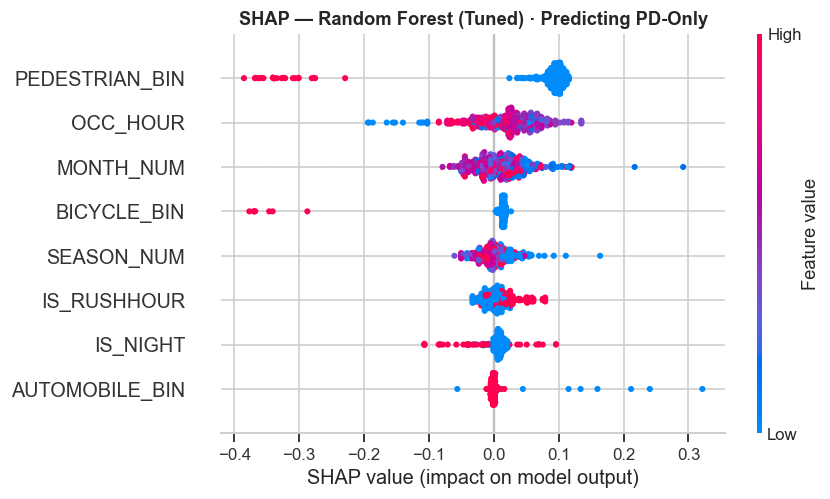


--- SHAP summary: class Injury (shape (500, 8)) ---


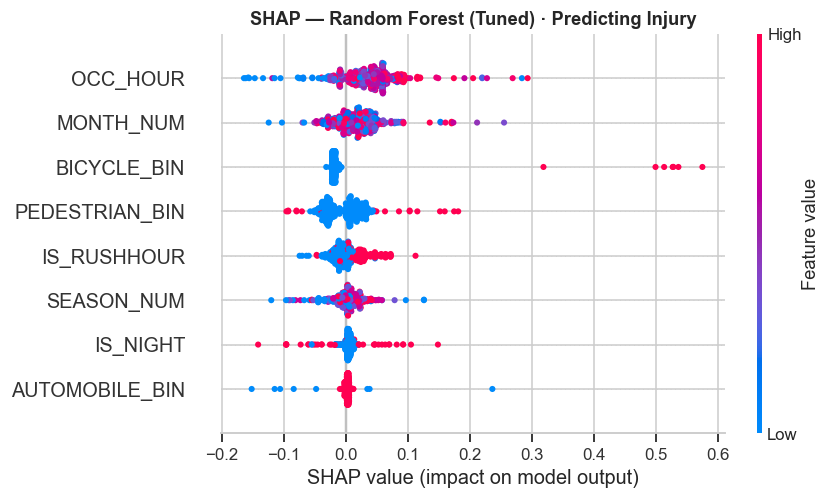


--- SHAP summary: class Fatal (shape (500, 8)) ---


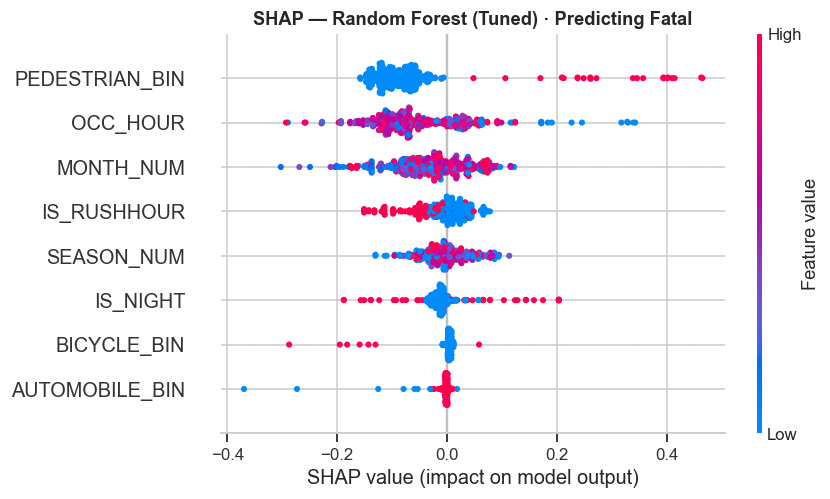

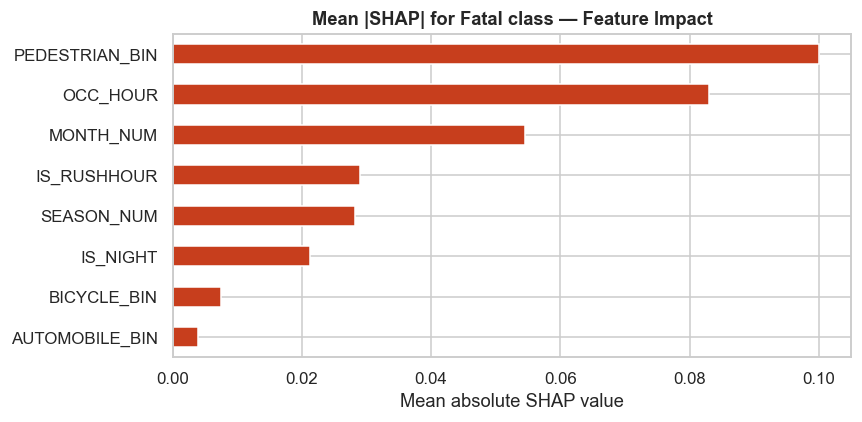

In [ ]:
# ── 10.3  SHAP explainability for final RF model ─────────────────────────────
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
    import shap

if "best_estimators" not in globals() or not best_estimators:
    raise RuntimeError("Run Section 7.3 GridSearchCV first (cell ~51).")

rf_model = best_estimators["Random Forest (Tuned)"]
feat_names = available if "available" in globals() else [f"f{i}" for i in range(X_test_sc.shape[1])]

SHAP_SAMPLE = min(500, len(X_test_sc))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test_sc), SHAP_SAMPLE, replace=False)
X_shap = X_test_sc[idx]
n_feat = X_shap.shape[1]

def _shap_for_class(shap_values, cls_idx: int, n_features: int) -> np.ndarray:
    """Align SHAP matrix to X columns (handles list/3D output + offset column)."""
    if isinstance(shap_values, list):
        sv = np.asarray(shap_values[cls_idx])
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv = shap_values[:, :, cls_idx]
    else:
        sv = np.asarray(shap_values)

    if sv.ndim == 2 and sv.shape[1] == n_features + 1:
        sv = sv[:, :-1]  # drop constant offset column (newer SHAP)
    if sv.ndim == 2 and sv.shape[1] > n_features:
        sv = sv[:, :n_features]
    return sv

print(f"Computing SHAP values for {SHAP_SAMPLE} test samples...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)

class_names = ["PD-Only", "Injury", "Fatal"]
for cls_idx, cls_name in enumerate(class_names):
    sv = _shap_for_class(shap_values, cls_idx, n_feat)
    print(f"\n--- SHAP summary: class {cls_name} (shape {sv.shape}) ---")
    shap.summary_plot(
        sv, X_shap, feature_names=feat_names,
        show=False, max_display=len(feat_names),
    )
    plt.title(f"SHAP — Random Forest (Tuned) · Predicting {cls_name}", fontweight="bold")
    plt.tight_layout()
    plt.show()

fatal_sv = _shap_for_class(shap_values, 2, n_feat)
fatal_shap = np.abs(fatal_sv).mean(axis=0)
fi_shap = pd.Series(fatal_shap, index=feat_names[: len(fatal_shap)]).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
fi_shap.plot(kind="barh", ax=ax, color="#C73E1D")
ax.set_title("Mean |SHAP| for Fatal class — Feature Impact", fontweight="bold")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


### Section 10.3 — Chart interpretation (SHAP explainability)

**SHAP summary plots (one per severity class)**

- Each dot is a test observation; **horizontal position** shows SHAP value (push toward or away from the predicted class).
- **Colour (red → blue):** Feature value magnitude for that row — e.g., high pedestrian involvement shifting Fatal probability upward.
- **Vertical feature order:** Features ranked by mean |SHAP| — top features are the primary drivers of model behaviour for that class.

**Fatal class |SHAP| bar chart**

- Ranks **global** feature importance for Fatal predictions on the tuned Random Forest.
- **Longer bars → stronger average influence** on Fatal severity scores; use this for feature governance and stakeholder briefings.

**Directional ethics framing:** SHAP satisfies the **explainability** requirement for trustworthy AI in public safety — it documents *why* a severity label was assigned, complementing fairness audits (Section 8) and multimodal fusion transparency (Sections 9.5–10.2).


---

**Findings & importance:** Ethics deliverable — shows **why** the model made each prediction (e.g., pedestrian involvement pushing severity up). Required for trustworthy AI in public-safety applications.

**What to check in the output:** SHAP summary/beeswarm plot — pedestrian and time-of-day features often dominate.


### 10.4 · Model Deployment

Serialize the tuned Random Forest + scaler for the Smart-Shield API / dashboard backend.


**What this cell does:** Saves all trained artifacts (`rf_tuned.joblib`, `scaler.joblib`, `tfidf_vectorizer.joblib`, etc.) to the `models/` folder for the Flask demo.

**How the code works:**
- Saves `rf_tuned.joblib`, `scaler.joblib`, `feature_names.joblib`, `tfidf_vectorizer.joblib`, and related artifacts to `models/`.
- Creates directory if missing; prints confirmation paths.


In [ ]:
# ── 10.4  Serialize models for deployment ────────────────────────────────────
import joblib
from nlp_brain import fit_tfidf
from pathlib import Path

MODEL_DIR = (REPO_ROOT / "models") if "REPO_ROOT" in globals() else Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

artifacts = {
    "rf_tuned": best_estimators["Random Forest (Tuned)"],
    "lr_tuned": best_estimators["Logistic Regression (Tuned)"],
    "scaler": scaler,
    "feature_names": available,
    "tfidf_vectorizer": tfidf_vec if "tfidf_vec" in globals() else fit_tfidf(),
}

paths = {}
for name, obj in artifacts.items():
    p = MODEL_DIR / f"{name}.joblib"
    joblib.dump(obj, p)
    paths[name] = str(p.resolve())
    print(f"  Saved {name} → {p}")

# Quick load test
rf_loaded = joblib.load(MODEL_DIR / "rf_tuned.joblib")
test_pred = rf_loaded.predict(X_test_sc[:5])
print(f"\nLoad test OK — sample preds: {test_pred}")

if TORCH_OK and "model_dnn" in dir() and model_dnn is not None:
    torch_path = MODEL_DIR / "dnn_smart_shield.pt"
    torch.save(model_dnn.state_dict(), torch_path)
    print(f"  Saved DNN weights → {torch_path}")

if TORCH_OK and "vision_model" in dir() and vision_model is not None:
    vis_path = MODEL_DIR / "vision_resnet18.pt"
    torch.save(vision_model.state_dict(), vis_path)
    print(f"  Saved Vision model → {vis_path}")

print("\n=== Sprint 3 Complete ===")
print("  ✓ NLP Brain (TF-IDF T scores)")
print("  ✓ Vision Brain (Section 6 V scores)")
print("  ✓ Safety Score fusion + dashboard")
print("  ✓ SHAP explainability")
print("  ✓ Models saved to ./models/")


  Saved rf_tuned → C:\Users\DELL\OneDrive - Sheridan College\Desktop\All Documents\PAIDA 2025 - 2026\SEMESTER 3\INFO53883 - AI & ML Capstone Project\models\rf_tuned.joblib
  Saved lr_tuned → C:\Users\DELL\OneDrive - Sheridan College\Desktop\All Documents\PAIDA 2025 - 2026\SEMESTER 3\INFO53883 - AI & ML Capstone Project\models\lr_tuned.joblib
  Saved scaler → C:\Users\DELL\OneDrive - Sheridan College\Desktop\All Documents\PAIDA 2025 - 2026\SEMESTER 3\INFO53883 - AI & ML Capstone Project\models\scaler.joblib
  Saved feature_names → C:\Users\DELL\OneDrive - Sheridan College\Desktop\All Documents\PAIDA 2025 - 2026\SEMESTER 3\INFO53883 - AI & ML Capstone Project\models\feature_names.joblib
  Saved tfidf_vectorizer → C:\Users\DELL\OneDrive - Sheridan College\Desktop\All Documents\PAIDA 2025 - 2026\SEMESTER 3\INFO53883 - AI & ML Capstone Project\models\tfidf_vectorizer.joblib

Load test OK — sample preds: [0 0 2 0 0]
  Saved DNN weights → C:\Users\DELL\OneDrive - Sheridan College\Desktop\All 

**Findings & importance:** Completes the pipeline — the notebook's outputs become deployable files. `demo/api_server.py` loads these artifacts to score live routes without retraining.

**What to check in the output:** List of saved files under `models/` — these are loaded by `demo/api_server.py` at startup.


In [ ]:
# ── PART SYNC → main notebook ──
import subprocess
import sys
from pathlib import Path

def _find_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "scripts" / "sync_notebook_parts.py").is_file():
            return base
    return Path.cwd()

_ROOT = _find_root()
rc = subprocess.run(
    [sys.executable, str(_ROOT / "scripts" / "sync_notebook_parts.py"),
     "--direction", "parts-to-main", "--only", "04_fusion_deploy.ipynb"],
    cwd=_ROOT,
).returncode
print("Synced to capstone_with_results.ipynb" if rc == 0 else f"Sync failed (exit {rc})")